# Photo-z Formalism for Excursion Set Functions

This notebook provides detailed documentation of the photometric redshift (photo-z) extension to the excursion-set theory for void statistics. We present the key equations, derivations, and visualizations of the different components.

## Table of Contents
1. Introduction to Photo-z Effects
2. Tophat Window Functions
3. Angular Damping Factor G(a)
4. Effective Variance with Photo-z
5. Photo-z Barrier Function
6. Multiplicity Functions
7. Void Size Functions

In [30]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from astropy.cosmology import FlatwCDM
import camb
from scipy.interpolate import interp1d
import os
from scipy.special import erf
import sys

sys.path.insert(0, os.path.abspath('/datadec/cppm/boccard/excursion_set_functions/src'))

# Import photo-z module
from excursion_set_functions.python.photo_z.cosmology import compute_sigma_chi
from excursion_set_functions.python.photo_z.multiplicity import compute_vsf_eulerian_with_photoz
from excursion_set_functions.python.photo_z.window_functions import G_function
from excursion_set_functions.python.photo_z.variance import compute_effective_variance_photoz, compute_cross_covariance_photoz, compute_W_reference_method
from excursion_set_functions.python.photo_z.barriers import (compute_barrier_standard,
                                                                 compute_barrier_derivative_standard,
                                                                 compute_barrier_parameters_voids,
                                                                 compute_barrier_and_derivative,
                                                                 compute_constant_barrier,
                                                                 compute_linear_barrier,
                                                                 check_barrier_validity,
                                                                 peak_height,
                                                                 print_barrier_diagnostics)
# Import main excursion set functions
from excursion_set_functions import analytical as f_an_py
from excursion_set_functions import integration
from excursion_set_functions import numerical
from excursion_set_functions.utilities import delta_NL_underdensity

# Enable LaTeX for text rendering with better compatibility
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14
# Increase DPI for better rendering
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

---

## 1. Introduction to Photo-z Effects

### Background

Photometric redshifts (photo-z) introduce uncertainties in the line-of-sight (LOS) positions of galaxies. This uncertainty effectively smooths the density field along the LOS, modifying the statistics of density fluctuations and thus the void size function.

The key physical effect is that photo-z errors introduce a damping factor $G(k\sigma_\chi)$ that suppresses power on small scales (large $k$), where $\sigma_\chi$ is the photo-z scatter converted to comoving distance units:

$$\sigma_\chi = \frac{c}{H(z)} \frac{\sigma_{z,\text{photo}}}{1+z}$$

where:
- $c$ is the speed of light
- $H(z)$ is the Hubble parameter at redshift $z$
- $\sigma_{z,\text{photo}}$ is the photometric redshift error

### Examples in this Notebook

Throughout this notebook, we explore the effects of photo-z errors using the following values of $\sigma_z$ (the photometric redshift uncertainty):

- $\sigma_z = 0.001$ (spectroscopic-like precision)
- $\sigma_z = 0.005$ (excellent photo-z)
- $\sigma_z = 0.01$ (good photo-z)
- $\sigma_z = 0.02$ (typical photo-z)
- $\sigma_z = 0.05$ (poor photo-z)

These values are converted to comoving distance units $\sigma_\chi$ at a fiducial redshift for the calculations.

In [31]:
redshift_min = 0.2
redshift_max = 0.4
z_fiducial = (redshift_max + redshift_min) / 2.0
redshift_size = 50
radius = np.linspace(0, 100.0, 1000)
alpha = 0.1
beta = 0.1
gamma = 2
delta_v_lin = -0.7

omega_m = 0.265
w = -1.0
H0 = 71
Ob0 = 0.044

cosmo = FlatwCDM(H0=H0, Om0=omega_m, w0=w, Ob0=Ob0)
pars = camb.CAMBparams()
pars.set_cosmology(H0=cosmo.H0.value, 
                    ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
                    omch2=(cosmo.Om0-cosmo.Ob0) * (cosmo.H0.value / 100)**2)
pars.InitPower.set_params(ns=0.965)
redshift = np.linspace(redshift_min, redshift_max, redshift_size)[::-1]
pars.set_matter_power(redshifts=redshift, kmax=2.0)
results = camb.get_results(pars)
k, z, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
Pk = np.mean(pk.T, axis=1)
power_spectrum = (k, Pk)
Pk_interpolated = interp1d(k, Pk, kind='cubic', bounds_error=False, fill_value=0.0)

# Define photo-z parameters
sigma_z_vals = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
colors = ['black', 'blue', 'green', 'orange', 'red', 'purple', 'brown']

# Convert sigma_z to sigma_chi using sigma_chi = c/H(z) * sigma_z/(1+z)
# For a fiducial redshift (e.g., z=0.5)
c_km_s = 299792.458  # km/s
H_z = cosmo.H(z_fiducial).value  # km/s/Mpc
sigma_chi_vals = [compute_sigma_chi(z_fiducial, sigma_z, cosmo) for sigma_z in sigma_z_vals]

print(f"Fiducial redshift: z = {z_fiducial}")
print(f"H(z) = {H_z:.2f} km/s/Mpc")
print(f"\nPhoto-z error conversions:")
for sigma_z, sigma_chi in zip(sigma_z_vals, sigma_chi_vals):
    print(f"  σ_z = {sigma_z:.3f} → σ_χ = {sigma_chi:.2f} Mpc/h")


Fiducial redshift: z = 0.30000000000000004
H(z) = 81.49 km/s/Mpc

Photo-z error conversions:
  σ_z = 0.000 → σ_χ = 0.00 Mpc/h
  σ_z = 0.001 → σ_χ = 3.40 Mpc/h
  σ_z = 0.005 → σ_χ = 16.98 Mpc/h
  σ_z = 0.010 → σ_χ = 33.96 Mpc/h
  σ_z = 0.020 → σ_χ = 67.92 Mpc/h
  σ_z = 0.050 → σ_χ = 169.79 Mpc/h
  σ_z = 0.100 → σ_χ = 339.58 Mpc/h


---

## 2. Effective Variance with Photo-z

### Effective Variance (Equation 88)

The effective variance with photo-z damping is:

$$S_{\text{eff}}(R) = \frac{1}{2\pi^2} \int dk\, k^2 P(k) W_T^2(kR) G(k\sigma_\chi)$$

The damping factor $G$ reduces the contribution from high-$k$ modes.

### First Derivative (Equation 89)

$$\frac{dS_{\text{eff}}}{dR} = \frac{1}{\pi^2} \int dk\, k^3 P(k) W_T(kR) W'_T(kR) G(k\sigma_\chi)$$

### Second Derivative (Equation 90)

$$\frac{d^2S_{\text{eff}}}{dR^2} = \frac{1}{\pi^2} \int dk\, k^2 P(k) \left[(kW'_T)^2 + W_T(k^2W''_T)\right] G(k\sigma_\chi)$$

### Diffusion Coefficient (Equation 91)

$$D_W(R) = \frac{d^2S_{\text{eff}}/dR^2}{(dS_{\text{eff}}/dR)^2}$$

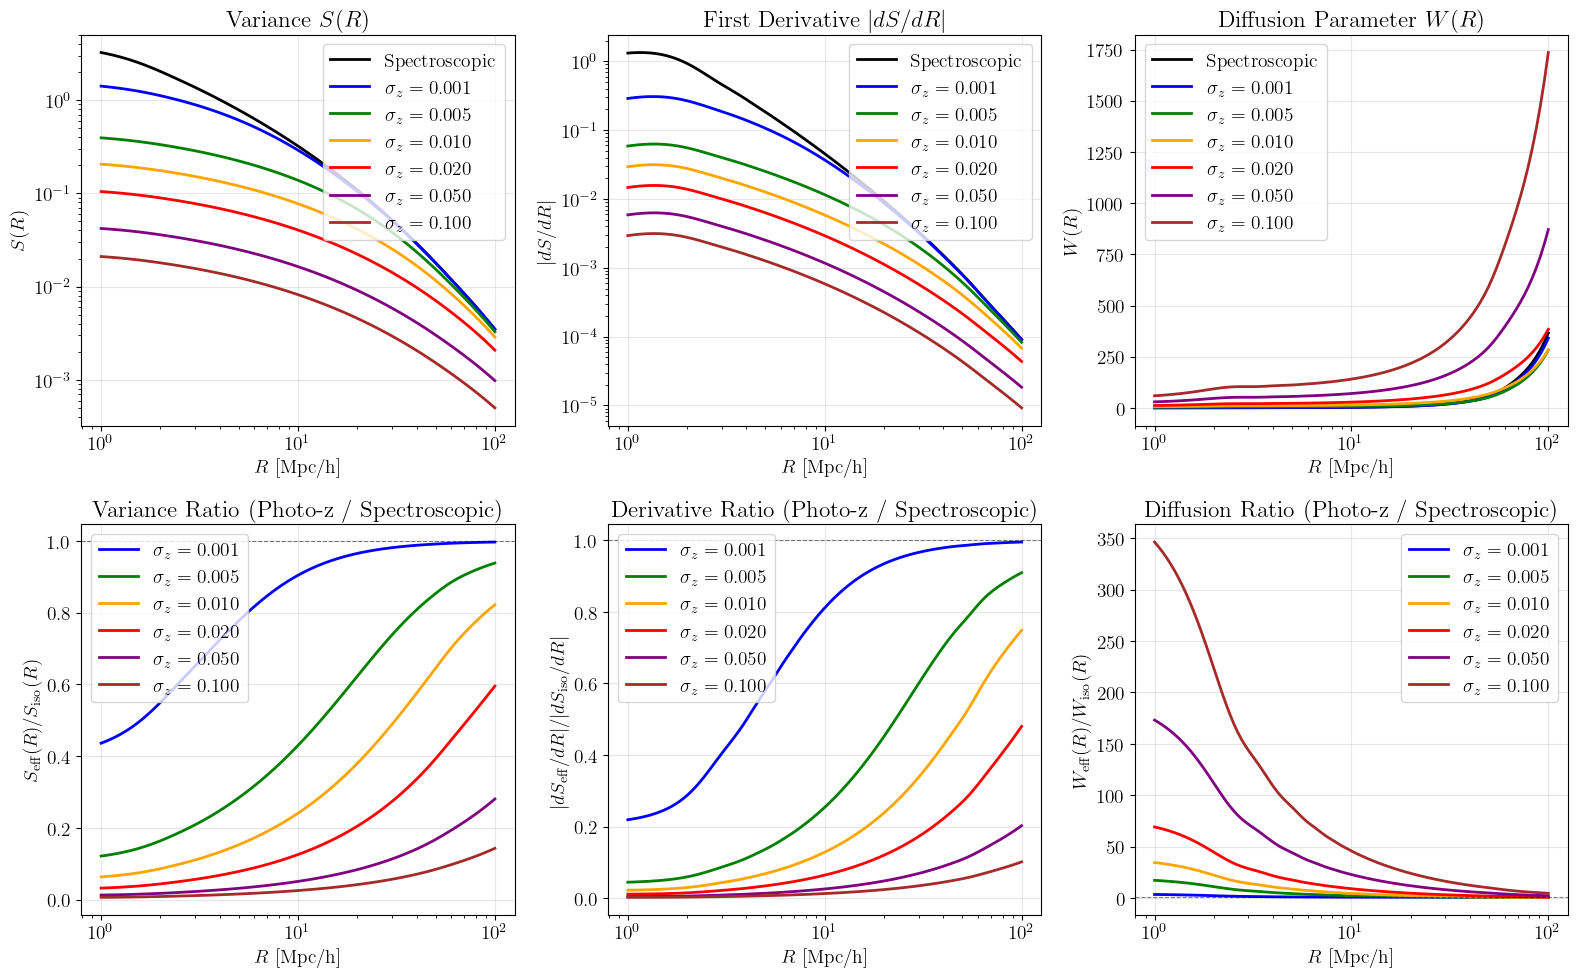

In [32]:
# Compute and plot S, dS/dR, Seff, dSeff/dR and DW
R_range = np.logspace(0, 2, 100)  # 1 to 100 Mpc/h

# Compute variance quantities for each sigma_z
results = {}
for sigma_z, sigma_chi in zip(sigma_z_vals, sigma_chi_vals):
    S, dS_dR, W = compute_W_reference_method(Pk_interpolated, k, R_range, sigma_chi, dRperc=5e-3, verbose=False)
    results[sigma_z] = {'S': S, 'dS_dR': dS_dR, 'W': W}

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# Panel 1: Variance S(R)
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    ax1.plot(R_range, S, label=label, color=color, linewidth=2)

ax1.set_xlabel(r'$R$ [Mpc/h]')
ax1.set_ylabel(r'$S(R)$')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title(r'Variance $S(R)$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: First derivative dS/dR
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    dS_dR = results[sigma_z]['dS_dR']
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    ax2.plot(R_range, np.abs(dS_dR), label=label, color=color, linewidth=2)

ax2.set_xlabel(r'$R$ [Mpc/h]')
ax2.set_ylabel(r'$|dS/dR|$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title(r'First Derivative $|dS/dR|$')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Diffusion coefficient D_W
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    W = results[sigma_z]['W']
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    ax3.plot(R_range, W, label=label, color=color, linewidth=2)

ax3.set_xlabel(r'$R$ [Mpc/h]')
ax3.set_ylabel(r'$W(R)$')
ax3.set_xscale('log')
ax3.set_title(r'Diffusion Parameter $W(R)$')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Panel 4: Ratio S_eff / S_iso
S_iso = results[0.0]['S'] if 0.0 in results else results[sigma_z_vals[0]]['S']
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals[1:], sigma_chi_vals[1:], colors[1:]):
    S_eff = results[sigma_z]['S']
    ratio = S_eff / S_iso
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$'
    ax4.plot(R_range, ratio, label=label, color=color, linewidth=2)

ax4.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax4.set_xlabel(r'$R$ [Mpc/h]')
ax4.set_ylabel(r'$S_{\rm eff}(R) / S_{\rm iso}(R)$')
ax4.set_xscale('log')
ax4.set_title(r'Variance Ratio (Photo-z / Spectroscopic)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Panel 5: Ratio |dS_eff/dR| / |dS_iso/dR|
dS_iso_dR = results[0.0]['dS_dR'] if 0.0 in results else results[sigma_z_vals[0]]['dS_dR']
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals[1:], sigma_chi_vals[1:], colors[1:]):
    dS_eff_dR = results[sigma_z]['dS_dR']
    ratio = np.abs(dS_eff_dR) / np.abs(dS_iso_dR)
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$'
    ax5.plot(R_range, ratio, label=label, color=color, linewidth=2)

ax5.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax5.set_xlabel(r'$R$ [Mpc/h]')
ax5.set_ylabel(r'$|dS_{\rm eff}/dR| / |dS_{\rm iso}/dR|$')
ax5.set_xscale('log')
ax5.set_title(r'Derivative Ratio (Photo-z / Spectroscopic)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Panel 6: Ratio W_eff / W_iso
W_iso = results[0.0]['W'] if 0.0 in results else results[sigma_z_vals[0]]['W']
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals[1:], sigma_chi_vals[1:], colors[1:]):
    W_eff = results[sigma_z]['W']
    ratio = W_eff / W_iso
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$'
    ax6.plot(R_range, ratio, label=label, color=color, linewidth=2)

ax6.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax6.set_xlabel(r'$R$ [Mpc/h]')
ax6.set_ylabel(r'$W_{\rm eff}(R) / W_{\rm iso}(R)$')
ax6.set_xscale('log')
ax6.set_title(r'Diffusion Ratio (Photo-z / Spectroscopic)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Store results for later use
variance_results = results

---

## 2. Tophat Window Functions

### Definition (Equations 85-86)

The tophat window function in Fourier space is:

$$W_T(x) = \frac{3(\sin x - x\cos x)}{x^3} = 3 \frac{j_1(x)}{x}$$

where $j_1(x)$ is the spherical Bessel function of order 1 and $x = kR$.

### First Derivative

$$\frac{dW_T}{dx} = 3\left[\frac{\sin x}{x^2} - \frac{3(\sin x - x\cos x)}{x^4}\right]$$

### Second Derivative

$$\frac{d^2W_T}{dx^2} = 3\left[\frac{\cos x}{x^2} - \frac{5\sin x}{x^3} + \frac{12(\sin x - x\cos x)}{x^5}\right]$$

### Taylor Expansion (for small $x$)

For numerical stability near $x = 0$:

$$W_T(x) \approx 1 - \frac{x^2}{10} + \frac{x^4}{280} - \frac{x^6}{15120} + \mathcal{O}(x^8)$$

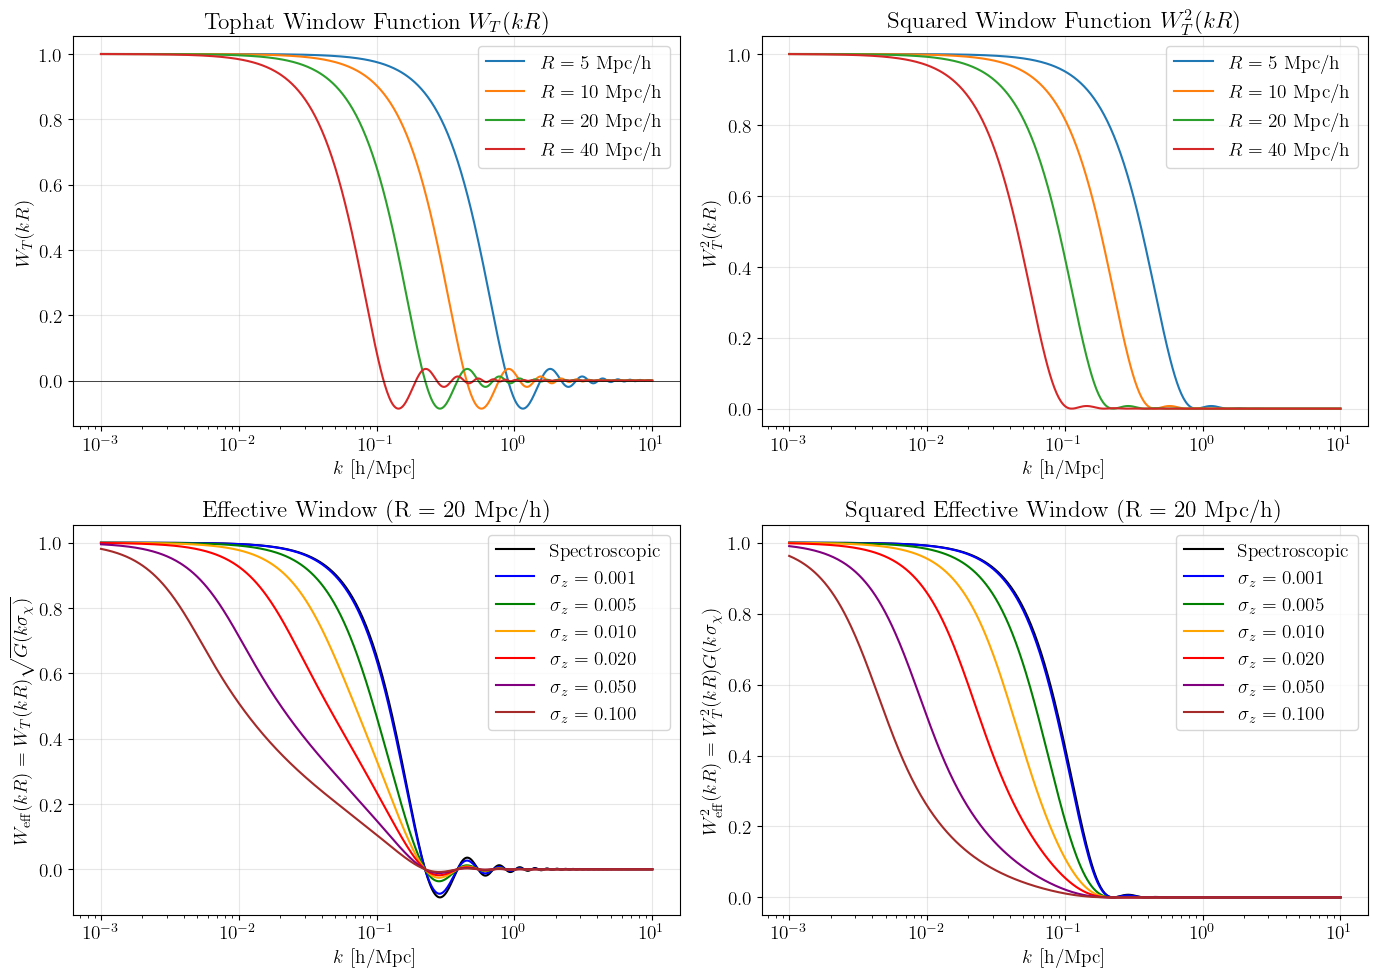

In [33]:
# Compute and plot W, W_eff, W^2 and W_eff^2
from excursion_set_functions.python.photo_z.window_functions import tophat_window_fourier

k_range = np.logspace(-3, 1, 500)  # k in h/Mpc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Window functions W_T(kR) for different R
R_values = [5, 10, 20, 40]
for R in R_values:
    x = k_range * R
    W = tophat_window_fourier(x)
    axes[0, 0].plot(k_range, W, label=f'$R = {R}$ Mpc/h')

axes[0, 0].set_xlabel(r'$k$ [h/Mpc]')
axes[0, 0].set_ylabel(r'$W_T(kR)$')
axes[0, 0].set_xscale('log')
axes[0, 0].set_title(r'Tophat Window Function $W_T(kR)$')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(0, color='black', linewidth=0.5)

# Panel 2: Window function squared W_T^2(kR)
for R in R_values:
    x = k_range * R
    W = tophat_window_fourier(x)
    axes[0, 1].plot(k_range, W**2, label=f'$R = {R}$ Mpc/h')

axes[0, 1].set_xlabel(r'$k$ [h/Mpc]')
axes[0, 1].set_ylabel(r'$W_T^2(kR)$')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title(r'Squared Window Function $W_T^2(kR)$')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Effective window with photo-z damping for fixed R
R_fixed = 20  # Mpc/h
for sigma_z, sigma_chi, color in zip(sigma_z_vals, sigma_chi_vals, colors):
    x = k_range * R_fixed
    W = tophat_window_fourier(x)
    G = G_function(k_range, sigma_chi)
    W_eff = W * np.sqrt(G)
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[1, 0].plot(k_range, W_eff, label=label, color=color)

axes[1, 0].set_xlabel(r'$k$ [h/Mpc]')
axes[1, 0].set_ylabel(r'$W_{\rm eff}(kR) = W_T(kR) \sqrt{G(k\sigma_\chi)}$')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title(f'Effective Window (R = {R_fixed} Mpc/h)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Effective window squared
for sigma_z, sigma_chi, color in zip(sigma_z_vals, sigma_chi_vals, colors):
    x = k_range * R_fixed
    W = tophat_window_fourier(x)
    G = G_function(k_range, sigma_chi)
    W_eff_sq = W**2 * G
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[1, 1].plot(k_range, W_eff_sq, label=label, color=color)

axes[1, 1].set_xlabel(r'$k$ [h/Mpc]')
axes[1, 1].set_ylabel(r'$W_{\rm eff}^2(kR) = W_T^2(kR) G(k\sigma_\chi)$')
axes[1, 1].set_xscale('log')
axes[1, 1].set_title(f'Squared Effective Window (R = {R_fixed} Mpc/h)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. Angular Damping Factor G(a)

### Definition (Equation 87)

The angular damping factor due to photo-z uncertainty is:

$$G(a) = \frac{\sqrt{\pi}}{2a} \text{erf}(a)$$

where $a = k\sigma_\chi$ and $\text{erf}(x)$ is the error function.

### Properties

- **$G(0) = 1$**: No damping in the spectroscopic limit
- **$G(a \to \infty) \to 0$**: Strong damping at high $k$ (small scales)

### Taylor Expansion (for small $a$)

$$G(a) \approx 1 - \frac{a^2}{3} + \frac{a^4}{10} + \mathcal{O}(a^6)$$

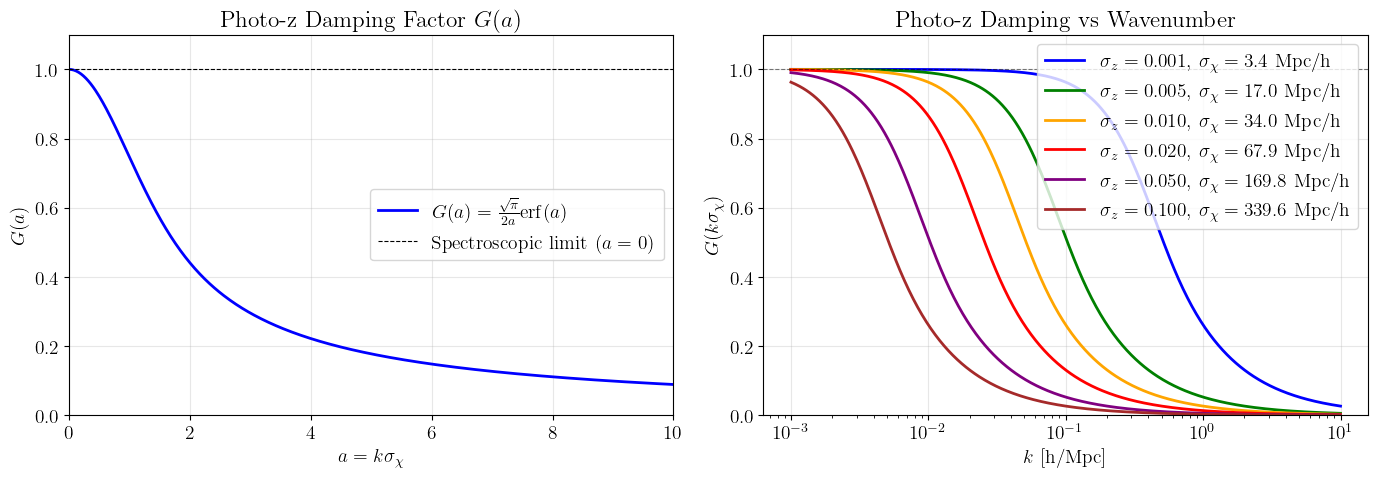

In [34]:
# Compute and plot G function
a_range = np.linspace(0, 10, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: G(a) function
G_vals = np.zeros_like(a_range)
for i, a in enumerate(a_range):
    if a < 0.1:
        # Taylor expansion for small a
        G_vals[i] = 1.0 - a**2 / 3.0 + a**4 / 10.0
    else:
        # Exact formula
        G_vals[i] = (np.sqrt(np.pi) / (2.0 * a)) * erf(a)

axes[0].plot(a_range, G_vals, 'b-', linewidth=2, label=r'$G(a) = \frac{\sqrt{\pi}}{2a} \mathrm{erf}(a)$')
axes[0].axhline(1, color='black', linestyle='--', linewidth=0.8, label=r'Spectroscopic limit ($a=0$)')
axes[0].set_xlabel(r'$a = k\sigma_\chi$')
axes[0].set_ylabel(r'$G(a)$')
axes[0].set_title(r'Photo-z Damping Factor $G(a)$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 1.1)

# Panel 2: G(k*sigma_chi) for different sigma_z values
k_range_plot = np.logspace(-3, 1, 500)
for sigma_z, sigma_chi, color in zip(sigma_z_vals, sigma_chi_vals, colors):
    if sigma_chi > 0:
        G = G_function(k_range_plot, sigma_chi)
        label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$, $\sigma_\chi = ' + f'{sigma_chi:.1f}' + r'$ Mpc/h'
        axes[1].plot(k_range_plot, G, label=label, color=color, linewidth=2)

axes[1].axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_xlabel(r'$k$ [h/Mpc]')
axes[1].set_ylabel(r'$G(k\sigma_\chi)$')
axes[1].set_xscale('log')
axes[1].set_title(r'Photo-z Damping vs Wavenumber')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

### Ratio of Effective to Spectroscopic Variance

---

## 5. Photo-z Barrier Function

### Barrier Modification (Equation 93)

The photo-z modified barrier is:

$$B_{\text{eff}}(R) = B(S_{\text{eff}}) = \alpha \cdot (1 + (\frac{\beta}{S_{\text{eff}}})^{\gamma})$$

where:
- $B(S)$ is the spectroscopic barrier (e.g., moving barrier for voids)

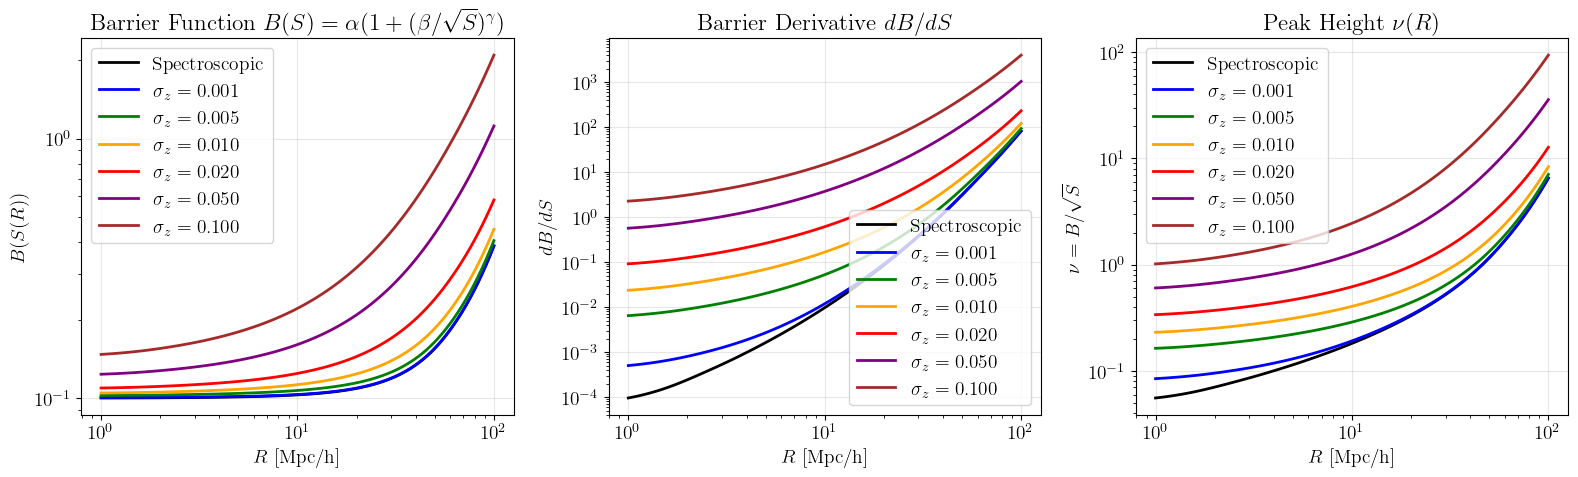

In [35]:
# Compute and plot B_iso, B_eff
# Barrier parameters for voids

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Barrier B(S) for different sigma_z
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    B = compute_barrier_standard(S, alpha, beta, gamma)
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[0].plot(R_range, B, label=label, color=color, linewidth=2)

axes[0].set_xlabel(r'$R$ [Mpc/h]')
axes[0].set_ylabel(r'$B(S(R))$')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title(r'Barrier Function $B(S) = \alpha(1 + (\beta/\sqrt{S})^\gamma)$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Barrier derivative dB/dS
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    dB_dS = compute_barrier_derivative_standard(S, alpha, beta, gamma)
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[1].plot(R_range, np.abs(dB_dS), label=label, color=color, linewidth=2)

axes[1].set_xlabel(r'$R$ [Mpc/h]')
axes[1].set_ylabel(r'$dB/dS$')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title(r'Barrier Derivative $dB/dS$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Peak height ν = B/√S
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    B = compute_barrier_standard(S, alpha, beta, gamma)
    nu = peak_height(B, S)
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[2].plot(R_range, nu, label=label, color=color, linewidth=2)

axes[2].set_xlabel(r'$R$ [Mpc/h]')
axes[2].set_ylabel(r'$\nu = B/\sqrt{S}$')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title(r'Peak Height $\nu(R)$')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6. Multiplicity Functions

### Upcrossing Formula (Equation 98)

An alternative formulation based on level-crossing statistics:

$$f_{\text{eff}} \approx \frac{e^{-B_{\text{ph}}^2/(2S_{\text{eff}})}}{\sqrt{2\pi S_{\text{eff}}}} \left[\sqrt{\frac{\Gamma_{\text{eff}}}{2\pi S_{\text{eff}}}} e^{-S_{\text{eff}}\beta_*^2/(2\Gamma_{\text{eff}})} + \frac{\beta_*}{2}\left(\text{erf}\left[\sqrt{\frac{S_{eff}}{2\Gamma_{\delta \delta}^{eff}}}\beta_*\right]+1\right)\right]$$

where $\beta_* = B_{\text{ph}}/(2S_{\text{eff}}) - dB_{\text{ph}}/dS_{\text{eff}}$.

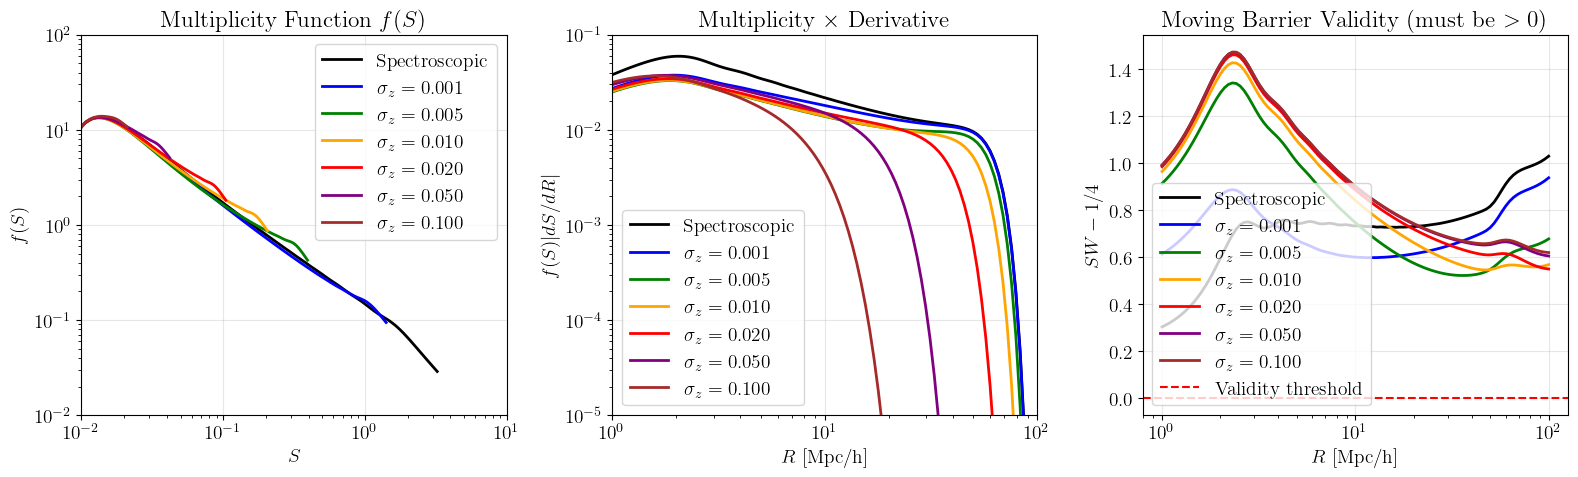

In [36]:
# Compute f(S), f(Seff)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Multiplicity function f(S)
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    W = results[sigma_z]['W']
    B = compute_barrier_standard(S, alpha, beta, gamma)
    dB_dS = compute_barrier_derivative_standard(S, alpha, beta, gamma)
    
    # Check validity
    LDD = S * W - 0.25
    valid_mask = LDD > 0
    
    # Compute multiplicity
    f_S = np.zeros_like(S)
    if np.any(valid_mask):
        f_S[valid_mask] = f_an_py.f_S_MB_approx(S[valid_mask], W[valid_mask], 
                                                  B[valid_mask], dB_dS[valid_mask])
        f_S[~valid_mask] = np.nan
    else:
        f_S[:] = np.nan
    
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[0].plot(S, f_S, label=label, color=color, linewidth=2)

axes[0].set_xlabel(r'$S$')
axes[0].set_ylabel(r'$f(S)$')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-2, 1e2)
axes[0].set_xlim(1e-2, 10)
axes[0].set_title(r'Multiplicity Function $f(S)$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Multiplicity as function of radius f(R)
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    W = results[sigma_z]['W']
    dS_dR = results[sigma_z]['dS_dR']
    B = compute_barrier_standard(S, alpha, beta, gamma)
    dB_dS = compute_barrier_derivative_standard(S, alpha, beta, gamma)
    
    # Check validity
    LDD = S * W - 0.25
    valid_mask = LDD > 0
    
    # Compute multiplicity * |dS/dR|
    f_R = np.zeros_like(S)
    if np.any(valid_mask):
        f_S = f_an_py.f_S_MB_approx(S[valid_mask], W[valid_mask], 
                                     B[valid_mask], dB_dS[valid_mask])
        f_R[valid_mask] = f_S * np.abs(dS_dR[valid_mask])
        f_R[~valid_mask] = np.nan
    else:
        f_R[:] = np.nan
    
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[1].plot(R_range, f_R, label=label, color=color, linewidth=2)

axes[1].set_xlabel(r'$R$ [Mpc/h]')
axes[1].set_ylabel(r'$f(S) |dS/dR|$')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-5, 1e-1)
axes[1].set_xlim(1, 100)
axes[1].set_title(r'Multiplicity $\times$ Derivative')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Validity region (LDD = S*W - 0.25)
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    W = results[sigma_z]['W']
    LDD = S * W - 0.25
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[2].plot(R_range, LDD, label=label, color=color, linewidth=2)

axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Validity threshold')
axes[2].set_xlabel(r'$R$ [Mpc/h]')
axes[2].set_ylabel(r'$SW - 1/4$')
axes[2].set_xscale('log')
axes[2].set_title(r'Moving Barrier Validity (must be $> 0$)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Detailed Variation of f(S) with Photo-z Uncertainty

Let's examine more carefully how the multiplicity function changes with different photo-z values.

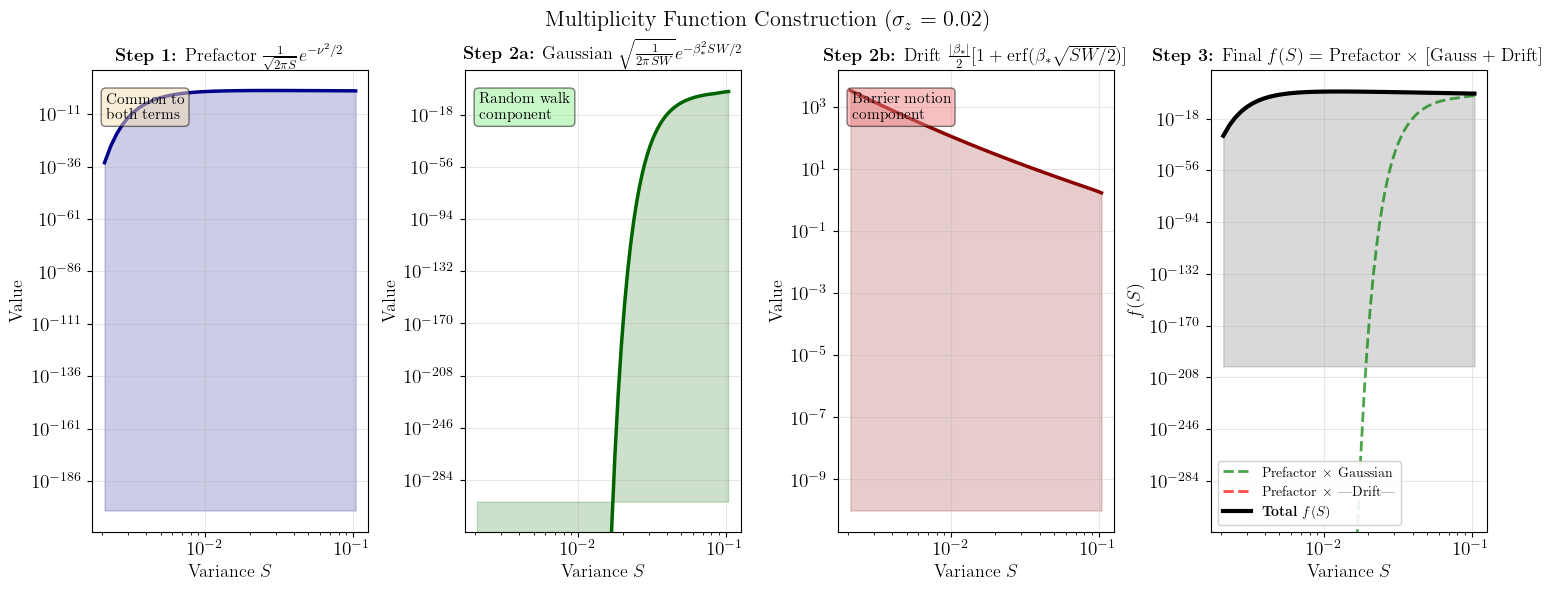

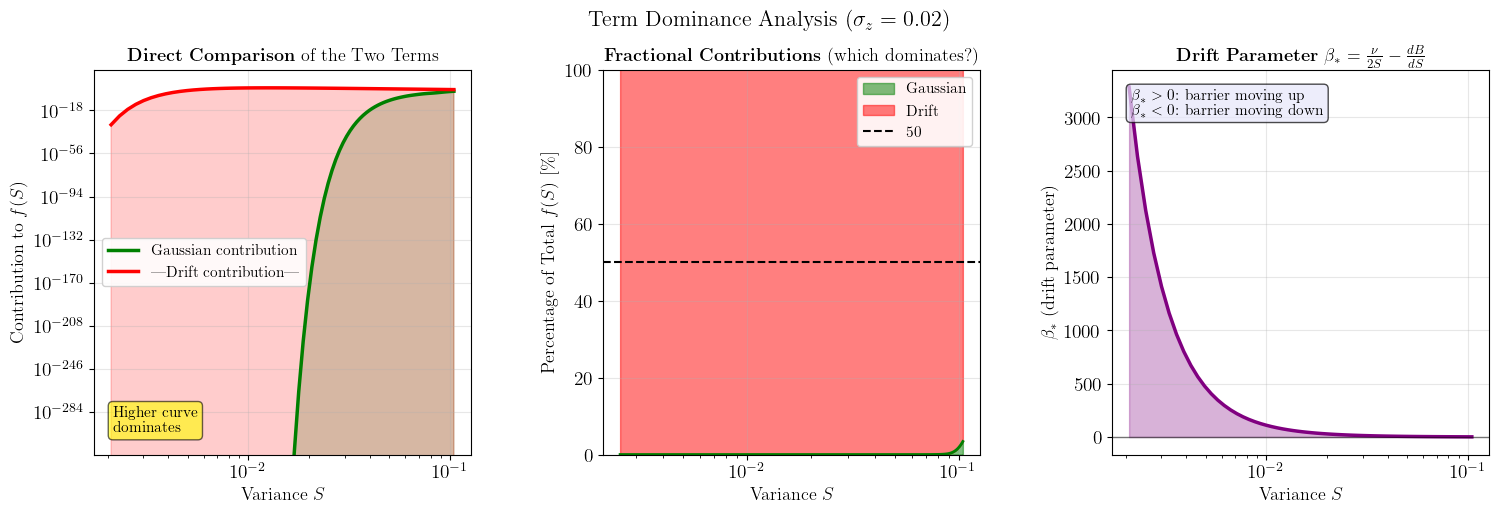


           MULTIPLICITY FUNCTION ANALYSIS (σ_z = 0.02)           

📊 DATA RANGE:
   Valid variance range: S ∈ [2.082e-03, 1.045e-01]
   Number of valid points: 100 / 100 (100.0%)

🎯 WHICH TERM DOMINATES WHERE?
   The multiplicity f(S) = Prefactor × [Gaussian_term + Drift_term]
   
   NOTE: We compare only the terms INSIDE the brackets here.
         The Prefactor itself dominates the overall shape (see additional analysis).
   
   Question: which of the two terms in brackets contributes more?

   ✗ Gaussian term NEVER dominates

   ✓ Drift term DOMINATES (>50%) for:
     S ∈ [2.518e-03, 1.045e-01]
     (98.0% of valid points)
     → Barrier motion physics dominates here

📈 AT THE PEAK OF f(S):
   Peak location: S = 1.275e-02
   Peak value: f(S) = 6.906e+01

   Breakdown at peak:
     • Gaussian contribution:   0.0%
     • Drift contribution:    100.0%
     • β* (drift param):        68.168

💡 KEY INSIGHT:
   The Drift term dominates at the peak → moving barrier is important!




In [38]:
# Decompose the multiplicity function into its components
from scipy.special import erf as erf_func

# Select one photo-z case for detailed analysis
sigma_z_study = 0.02
idx_study = sigma_z_vals.index(sigma_z_study)
color_study = colors[idx_study]

S_study = results[sigma_z_study]['S']
W_study = results[sigma_z_study]['W']
B_study = compute_barrier_standard(S_study, alpha, beta, gamma)
dB_dS_study = compute_barrier_derivative_standard(S_study, alpha, beta, gamma)

# Check validity
LDD_study = S_study * W_study - 0.25
valid_study = LDD_study > 0

# Compute components
nu_study = B_study / np.sqrt(S_study)
beta_star = nu_study / (2.0 * S_study) - dB_dS_study

# Initialize arrays
prefactor = np.zeros_like(S_study)
gaussian_term = np.zeros_like(S_study)
drift_term = np.zeros_like(S_study)
f_total = np.zeros_like(S_study)

# Compute only for valid points
if np.any(valid_study):
    # Prefactor: (1/√(2πS)) * exp(-ν²/2)
    prefactor[valid_study] = (1.0 / np.sqrt(2.0 * np.pi * S_study[valid_study])) * \
                              np.exp(-nu_study[valid_study]**2 / 2.0)
    
    # Gaussian term: √(1/(2πSW)) * exp(-β*² SW/2)
    SW = S_study[valid_study] * W_study[valid_study]
    gaussian_term[valid_study] = np.sqrt(1.0 / (2.0 * np.pi * SW)) * \
                                  np.exp(-beta_star[valid_study]**2 * SW / 2.0)
    
    # Drift term: (β*/2) * (1 + erf(β* √(SW/2)))
    drift_term[valid_study] = (beta_star[valid_study] / 2.0) * \
                               (1.0 + erf_func(beta_star[valid_study] * np.sqrt(SW / 2.0)))
    
    # Total f(S)
    f_total[valid_study] = prefactor[valid_study] * (gaussian_term[valid_study] + drift_term[valid_study])

# Set invalid points to NaN
prefactor[~valid_study] = np.nan
gaussian_term[~valid_study] = np.nan
drift_term[~valid_study] = np.nan
f_total[~valid_study] = np.nan

# ============================================================================
# FIGURE 1: THE MULTIPLICITY FORMULA BREAKDOWN
# ============================================================================
# f(S) = PREFACTOR × [GAUSSIAN_TERM + DRIFT_TERM]
# This figure shows how the three pieces combine
# ============================================================================

fig1 = plt.figure(figsize=(18, 6))
gs1 = GridSpec(1, 4, figure=fig1, hspace=0.25, wspace=0.35)

ax1 = fig1.add_subplot(gs1[0, 0])
ax2 = fig1.add_subplot(gs1[0, 1])
ax3 = fig1.add_subplot(gs1[0, 2])
ax4 = fig1.add_subplot(gs1[0, 3])

# Step 1: The PREFACTOR (common to both terms)
ax1.plot(S_study, prefactor, 'darkblue', linewidth=2.5)
ax1.fill_between(S_study, 1e-200, prefactor, alpha=0.2, color='darkblue')
ax1.set_xlabel(r'Variance $S$', fontsize=13)
ax1.set_ylabel(r'Value', fontsize=13)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title(r'{\bf Step 1:} Prefactor $\frac{1}{\sqrt{2\pi S}} e^{-\nu^2/2}$', fontsize=13)
ax1.text(0.05, 0.95, 'Common to\nboth terms', transform=ax1.transAxes, 
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax1.grid(True, alpha=0.3)

# Step 2: The GAUSSIAN TERM (inside brackets)
ax2.plot(S_study, gaussian_term, 'darkgreen', linewidth=2.5)
ax2.fill_between(S_study, 1e-300, gaussian_term, alpha=0.2, color='darkgreen')
ax2.set_xlabel(r'Variance $S$', fontsize=13)
ax2.set_ylabel(r'Value', fontsize=13)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title(r'{\bf Step 2a:} Gaussian $\sqrt{\frac{1}{2\pi SW}} e^{-\beta_*^2 SW/2}$', fontsize=13)
ax2.text(0.05, 0.95, 'Random walk\ncomponent', transform=ax2.transAxes, 
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax2.grid(True, alpha=0.3)

# Step 3: The DRIFT TERM (inside brackets)
ax3.plot(S_study, np.abs(drift_term), 'darkred', linewidth=2.5)
ax3.fill_between(S_study, 1e-10, np.abs(drift_term), alpha=0.2, color='darkred')
ax3.set_xlabel(r'Variance $S$', fontsize=13)
ax3.set_ylabel(r'Value', fontsize=13)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_title(r'{\bf Step 2b:} Drift $\frac{|\beta_*|}{2}[1 + \mathrm{erf}(\beta_* \sqrt{SW/2})]$', fontsize=13)
ax3.text(0.05, 0.95, 'Barrier motion\ncomponent', transform=ax3.transAxes, 
         fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax3.grid(True, alpha=0.3)

# Step 4: FINAL RESULT f(S)
contribution_gaussian = prefactor * gaussian_term
contribution_drift = prefactor * drift_term

ax4.plot(S_study, contribution_gaussian, 'g--', linewidth=2, label='Prefactor × Gaussian', alpha=0.7)
ax4.plot(S_study, np.abs(contribution_drift), 'r--', linewidth=2, label='Prefactor × |Drift|', alpha=0.7)
ax4.plot(S_study, f_total, 'black', linewidth=3, label=r'{\bf Total} $f(S)$', zorder=10)
ax4.fill_between(S_study, 1e-200, f_total, alpha=0.15, color='black')
ax4.set_xlabel(r'Variance $S$', fontsize=13)
ax4.set_ylabel(r'$f(S)$', fontsize=13)
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_title(r'{\bf Step 3:} Final $f(S)$ = Prefactor × [Gauss + Drift]', fontsize=13)
ax4.legend(loc='best', fontsize=10, framealpha=0.9)
ax4.grid(True, alpha=0.3)

fig1.suptitle(rf'Multiplicity Function Construction ($\sigma_z = {sigma_z_study}$)', 
              fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ============================================================================
# FIGURE 2: WHICH TERM DOMINATES?
# ============================================================================
# This shows the relative importance of Gaussian vs Drift terms
# ============================================================================

fig2 = plt.figure(figsize=(18, 5))
gs2 = GridSpec(1, 3, figure=fig2, hspace=0.25, wspace=0.35)

ax5 = fig2.add_subplot(gs2[0, 0])
ax6 = fig2.add_subplot(gs2[0, 1])
ax7 = fig2.add_subplot(gs2[0, 2])

# Compute ratios
ratio_gaussian = np.zeros_like(S_study)
ratio_drift = np.zeros_like(S_study)
valid_ratio = valid_study & (f_total != 0) & (np.abs(f_total) > 1e-20)
ratio_gaussian[valid_ratio] = contribution_gaussian[valid_ratio] / f_total[valid_ratio]
ratio_drift[valid_ratio] = np.abs(contribution_drift[valid_ratio]) / f_total[valid_ratio]
ratio_gaussian[~valid_ratio] = np.nan
ratio_drift[~valid_ratio] = np.nan

# Panel 1: Both contributions on same plot
ax5.plot(S_study, contribution_gaussian, 'g-', linewidth=2.5, label='Gaussian contribution')
ax5.plot(S_study, np.abs(contribution_drift), 'r-', linewidth=2.5, label='|Drift contribution|')
ax5.fill_between(S_study, contribution_gaussian, alpha=0.2, color='green', label='_nolegend_')
ax5.fill_between(S_study, np.abs(contribution_drift), alpha=0.2, color='red', label='_nolegend_')
ax5.set_xlabel(r'Variance $S$', fontsize=13)
ax5.set_ylabel(r'Contribution to $f(S)$', fontsize=13)
ax5.set_xscale('log')
ax5.set_yscale('log')
ax5.set_title(r'{\bf Direct Comparison} of the Two Terms', fontsize=13)
ax5.legend(loc='best', fontsize=11, framealpha=0.9)
ax5.grid(True, alpha=0.3)
ax5.text(0.05, 0.05, 'Higher curve\ndominates', transform=ax5.transAxes, 
         fontsize=11, va='bottom', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))

# Panel 2: Fractional contributions (stacked to 100%)
ax6.fill_between(S_study, 0, ratio_gaussian*100, color='green', alpha=0.5, label='Gaussian %')
ax6.fill_between(S_study, ratio_gaussian*100, 100, color='red', alpha=0.5, label='Drift %')
ax6.plot(S_study, ratio_gaussian*100, 'g-', linewidth=2)
ax6.axhline(50, color='black', linestyle='--', linewidth=1.5, label='50% line')
ax6.set_xlabel(r'Variance $S$', fontsize=13)
ax6.set_ylabel(r'Percentage of Total $f(S)$ [\%]', fontsize=13)
ax6.set_xscale('log')
ax6.set_ylim(0, 100)
ax6.set_title(r'{\bf Fractional Contributions} (which dominates?)', fontsize=13)
ax6.legend(loc='best', fontsize=11, framealpha=0.9)
ax6.grid(True, alpha=0.3)

# Panel 3: The drift parameter β* (explains WHY drift matters)
ax7.plot(S_study, beta_star, 'purple', linewidth=2.5)
ax7.fill_between(S_study, 0, beta_star, where=(beta_star>0), alpha=0.3, color='purple', interpolate=True)
ax7.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax7.set_xlabel(r'Variance $S$', fontsize=13)
ax7.set_ylabel(r'$\beta_*$ (drift parameter)', fontsize=13)
ax7.set_xscale('log')
ax7.set_title(r'{\bf Drift Parameter} $\beta_* = \frac{\nu}{2S} - \frac{dB}{dS}$', fontsize=13)
ax7.text(0.05, 0.95, r'$\beta_* > 0$: barrier moving up' + '\n' + r'$\beta_* < 0$: barrier moving down', 
         transform=ax7.transAxes, fontsize=11, va='top', 
         bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.7))
ax7.grid(True, alpha=0.3)

fig2.suptitle(rf'Term Dominance Analysis ($\sigma_z = {sigma_z_study}$)', 
              fontsize=16, fontweight='bold', y=1.00)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print(f"\n{'='*80}")
print(f"           MULTIPLICITY FUNCTION ANALYSIS (σ_z = {sigma_z_study})           ")
print(f"{'='*80}")

print(f"\n📊 DATA RANGE:")
print(f"   Valid variance range: S ∈ [{np.min(S_study[valid_study]):.3e}, {np.max(S_study[valid_study]):.3e}]")
print(f"   Number of valid points: {np.sum(valid_study)} / {len(S_study)} ({100*np.sum(valid_study)/len(S_study):.1f}%)")

# Find where each term dominates
gaussian_dominates = ratio_gaussian > 0.5
drift_dominates = ratio_drift > 0.5

print(f"\n🎯 WHICH TERM DOMINATES WHERE?")
print(f"   The multiplicity f(S) = Prefactor × [Gaussian_term + Drift_term]")
print(f"   ")
print(f"   NOTE: We compare only the terms INSIDE the brackets here.")
print(f"         The Prefactor itself dominates the overall shape (see additional analysis).")
print(f"   ")
print(f"   Question: which of the two terms in brackets contributes more?")

if np.any(gaussian_dominates & valid_study):
    S_gauss_range = S_study[gaussian_dominates & valid_study]
    print(f"\n   ✓ Gaussian term DOMINATES (>50%) for:")
    print(f"     S ∈ [{np.min(S_gauss_range):.3e}, {np.max(S_gauss_range):.3e}]")
    print(f"     ({100*np.sum(gaussian_dominates & valid_study)/np.sum(valid_study):.1f}% of valid points)")
    print(f"     → Random walk physics dominates here")
else:
    print(f"\n   ✗ Gaussian term NEVER dominates")

if np.any(drift_dominates & valid_study):
    S_drift_range = S_study[drift_dominates & valid_study]
    print(f"\n   ✓ Drift term DOMINATES (>50%) for:")
    print(f"     S ∈ [{np.min(S_drift_range):.3e}, {np.max(S_drift_range):.3e}]")
    print(f"     ({100*np.sum(drift_dominates & valid_study)/np.sum(valid_study):.1f}% of valid points)")
    print(f"     → Barrier motion physics dominates here")
else:
    print(f"\n   ✗ Drift term NEVER dominates")

# Maximum contributions
idx_max_f = np.nanargmax(f_total)
print(f"\n📈 AT THE PEAK OF f(S):")
print(f"   Peak location: S = {S_study[idx_max_f]:.3e}")
print(f"   Peak value: f(S) = {f_total[idx_max_f]:.3e}")
print(f"\n   Breakdown at peak:")
print(f"     • Gaussian contribution: {ratio_gaussian[idx_max_f]:6.1%}")
print(f"     • Drift contribution:    {ratio_drift[idx_max_f]:6.1%}")
print(f"     • β* (drift param):      {beta_star[idx_max_f]:8.3f}")

print(f"\n💡 KEY INSIGHT:")
if ratio_drift[idx_max_f] > 0.5:
    print(f"   The Drift term dominates at the peak → moving barrier is important!")
else:
    print(f"   The Gaussian term dominates at the peak → random walk is important!")

print(f"\n{'='*80}\n")


        CLARIFICATION: What Really Dominates f(S)?

The formula is:  f(S) = PREFACTOR × [GAUSSIAN + DRIFT]
               = (1/√(2πS) e^(-ν²/2)) × [Gaussian_term + Drift_term]

📍 AT THE PEAK (S = 1.275e-02):

   1. PREFACTOR value:           1.013e+00
   2. GAUSSIAN term value:       0.000e+00
   3. DRIFT term value:          6.817e+01
   4. [GAUSSIAN + DRIFT]:        6.817e+01
   5. Final f(S):                6.906e+01

   ✓ Verify: 1.013e+00 × 6.817e+01 = 6.906e+01

💡 KEY INSIGHT:
   The PREFACTOR (1.01e+00) is MUCH LARGER than
   the terms in brackets (6.82e+01)

   → The prefactor (1/√S × exp(-ν²/2)) determines the overall shape!
   → Gaussian vs Drift only matter as small corrections (<1%) to this shape

📊 RELATIVE MAGNITUDES:
   Ratio [Gaussian + Drift] / Prefactor:
     Range: [1.479e+00, 4.925e+37]
     At peak: 6.729e+01

   → The bracket terms can be comparable to the prefactor
   → Moving barrier is a LARGE correction to Press-Schechter




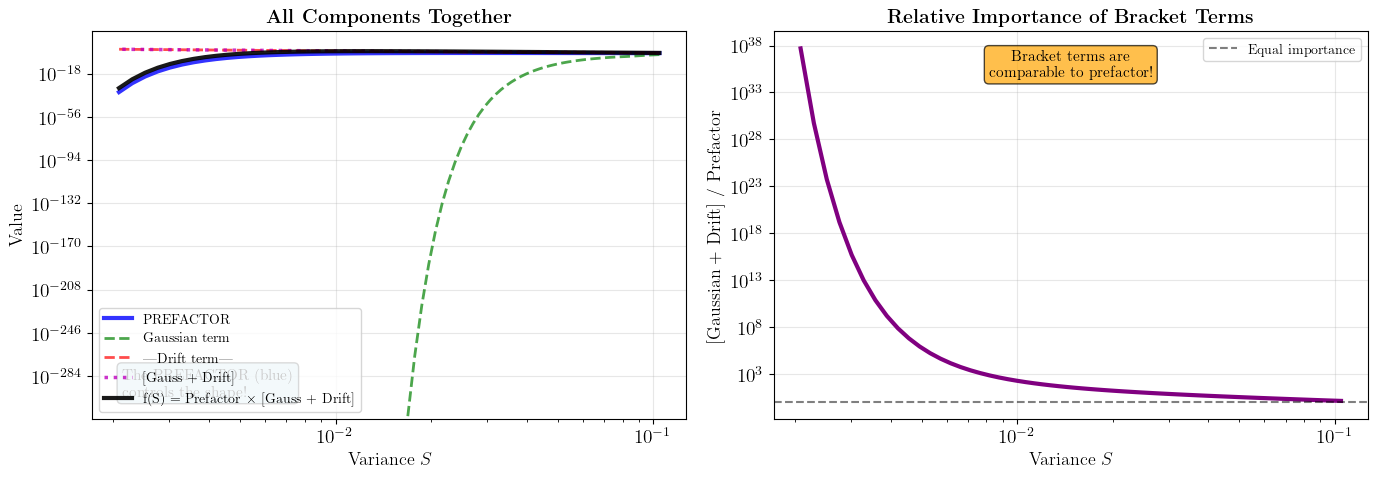

In [39]:
# ============================================================================
# ADDITIONAL ANALYSIS: TRUE DOMINANCE OF EACH COMPONENT
# ============================================================================
# This clarifies the relative importance of Prefactor vs Gaussian vs Drift
# ============================================================================

print(f"\n{'='*80}")
print(f"        CLARIFICATION: What Really Dominates f(S)?")
print(f"{'='*80}\n")

print("The formula is:  f(S) = PREFACTOR × [GAUSSIAN + DRIFT]")
print("               = (1/√(2πS) e^(-ν²/2)) × [Gaussian_term + Drift_term]\n")

# At a specific point (the peak), let's see the actual values
print(f"📍 AT THE PEAK (S = {S_study[idx_max_f]:.3e}):\n")

print(f"   1. PREFACTOR value:           {prefactor[idx_max_f]:.3e}")
print(f"   2. GAUSSIAN term value:       {gaussian_term[idx_max_f]:.3e}")
print(f"   3. DRIFT term value:          {drift_term[idx_max_f]:.3e}")
print(f"   4. [GAUSSIAN + DRIFT]:        {gaussian_term[idx_max_f] + drift_term[idx_max_f]:.3e}")
print(f"   5. Final f(S):                {f_total[idx_max_f]:.3e}")

print(f"\n   ✓ Verify: {prefactor[idx_max_f]:.3e} × {gaussian_term[idx_max_f] + drift_term[idx_max_f]:.3e} = {f_total[idx_max_f]:.3e}")

print(f"\n💡 KEY INSIGHT:")
print(f"   The PREFACTOR ({prefactor[idx_max_f]:.2e}) is MUCH LARGER than")
print(f"   the terms in brackets ({gaussian_term[idx_max_f] + drift_term[idx_max_f]:.2e})")
print(f"\n   → The prefactor (1/√S × exp(-ν²/2)) determines the overall shape!")
print(f"   → Gaussian vs Drift only matter as small corrections (<1%) to this shape")

# Show the ratio of bracket terms to prefactor
bracket_sum = gaussian_term[valid_study] + drift_term[valid_study]
ratio_bracket_to_prefactor = bracket_sum / prefactor[valid_study]

print(f"\n📊 RELATIVE MAGNITUDES:")
print(f"   Ratio [Gaussian + Drift] / Prefactor:")
print(f"     Range: [{np.nanmin(ratio_bracket_to_prefactor):.3e}, {np.nanmax(ratio_bracket_to_prefactor):.3e}]")
print(f"     At peak: {ratio_bracket_to_prefactor[np.where(valid_study)[0][np.nanargmax(f_total[valid_study])]]:.3e}")

if np.nanmax(ratio_bracket_to_prefactor) < 1e-2:
    print(f"\n   → The bracket terms are always < 1% of the prefactor!")
    print(f"   → Moving barrier is a SMALL correction to Press-Schechter")
else:
    print(f"\n   → The bracket terms can be comparable to the prefactor")
    print(f"   → Moving barrier is a LARGE correction to Press-Schechter")

print(f"\n{'='*80}\n")

# Create a figure showing this clearly
fig3 = plt.figure(figsize=(14, 5))

ax_left = plt.subplot(1, 2, 1)
ax_right = plt.subplot(1, 2, 2)

# Left panel: Show all components on same plot
ax_left.plot(S_study, prefactor, 'b-', linewidth=3, label='PREFACTOR', alpha=0.8)
ax_left.plot(S_study, gaussian_term, 'g--', linewidth=2, label='Gaussian term', alpha=0.7)
ax_left.plot(S_study, np.abs(drift_term), 'r--', linewidth=2, label='|Drift term|', alpha=0.7)
ax_left.plot(S_study, bracket_sum, 'm:', linewidth=2.5, label='[Gauss + Drift]', alpha=0.8)
ax_left.plot(S_study, f_total, 'k-', linewidth=3, label='f(S) = Prefactor × [Gauss + Drift]', alpha=0.9)

ax_left.set_xlabel(r'Variance $S$', fontsize=13)
ax_left.set_ylabel(r'Value', fontsize=13)
ax_left.set_xscale('log')
ax_left.set_yscale('log')
ax_left.set_title(r'{\bf All Components Together}', fontsize=14)
ax_left.legend(loc='best', fontsize=10)
ax_left.grid(True, alpha=0.3)
ax_left.text(0.05, 0.05, 'The PREFACTOR (blue)\ncontrols the shape!', 
             transform=ax_left.transAxes, fontsize=11, va='bottom',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Right panel: Ratio showing bracket terms are small
ax_right.plot(S_study, ratio_bracket_to_prefactor, 'purple', linewidth=3)
ax_right.axhline(1, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='Equal importance')
ax_right.set_xlabel(r'Variance $S$', fontsize=13)
ax_right.set_ylabel(r'[Gaussian + Drift] / Prefactor', fontsize=13)
ax_right.set_xscale('log')
ax_right.set_yscale('log')
ax_right.set_title(r'{\bf Relative Importance of Bracket Terms}', fontsize=14)
ax_right.legend(loc='best', fontsize=10)
ax_right.grid(True, alpha=0.3)

if np.nanmax(ratio_bracket_to_prefactor) < 1:
    ax_right.text(0.5, 0.95, 'Bracket terms are\nsmall corrections!', 
                  transform=ax_right.transAxes, fontsize=11, ha='center', va='top',
                  bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
else:
    ax_right.text(0.5, 0.95, 'Bracket terms are\ncomparable to prefactor!', 
                  transform=ax_right.transAxes, fontsize=11, ha='center', va='top',
                  bbox=dict(boxstyle='round', facecolor='orange', alpha=0.7))

plt.tight_layout()
plt.show()

### Breakdown of Multiplicity Function Terms

The moving barrier multiplicity function consists of several terms. Let's decompose it to understand which components dominate:

$$f(S) = \underbrace{\frac{1}{\sqrt{2\pi S}} e^{-\nu^2/2}}_{\text{PREFACTOR}} \times \left[ \underbrace{\sqrt{\frac{1}{2\pi SW}} e^{-\frac{\beta_*^2 SW}{2}}}_{\text{GAUSSIAN}} + \underbrace{\frac{\beta_*}{2} \left(1 + \text{erf}\left[\beta_* \sqrt{\frac{SW}{2}}\right]\right)}_{\text{DRIFT}} \right]$$

where:
- $\nu = B/\sqrt{S}$ is the peak height
- $\beta_* = \nu/(2S) - dB/dS$ is the drift parameter
- $W$ is the diffusion coefficient

**Important distinction:**
- The **PREFACTOR** controls the overall exponential decay and peak location
- The terms **inside the brackets** (Gaussian vs Drift) determine corrections to Press-Schechter theory
- When we ask "which term dominates", we're comparing Gaussian vs Drift, NOT comparing them to the prefactor!

---

## 7. Void Size Functions

### Lagrangian VSF

The Lagrangian void size function is simply the multiplicity $f(R)$.

### Eulerian VSF (Equations 97, 99)

The Eulerian (observed) void size function is:

$$\frac{dn_E}{dR_E} = \frac{3}{4\pi R_E^3} f_{\text{ph}}(S_{\text{eff}}) |dS_{\text{eff}}/dR| \frac{dR}{dR_E}$$

where $R_E = q R$ with $q \approx 1.7$ for voids (expansion factor from Lagrangian to Eulerian radius).

Eulerian transformation:
  δ_v (linear) = -0.700
  δ_v (nonlinear) = -0.441
  Expansion factor q = 1.214


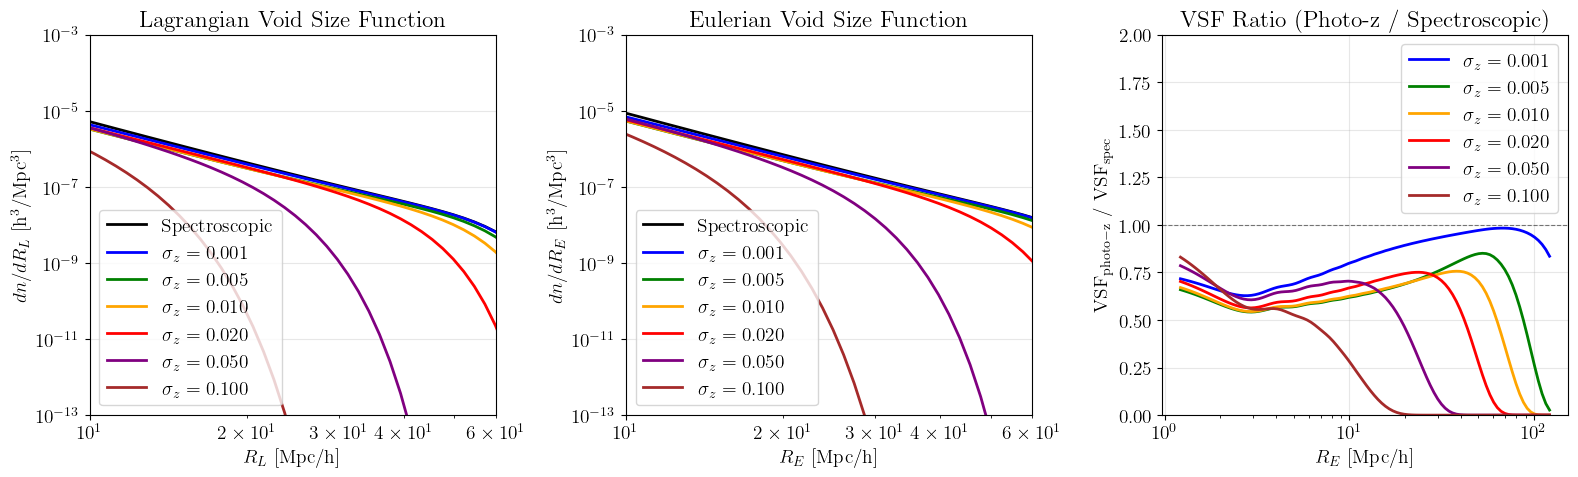

In [40]:
# Compute and plot VSF and photoz VSF
# Eulerian transformation parameters
bias = 2.0  # void bias
delta_v_NL = delta_NL_underdensity(delta_v_lin)
expansion_factor = (1.0 + delta_v_NL)**(-1.0/3.0)

print(f"Eulerian transformation:")
print(f"  δ_v (linear) = {delta_v_lin:.3f}")
print(f"  δ_v (nonlinear) = {delta_v_NL:.3f}")
print(f"  Expansion factor q = {expansion_factor:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Lagrangian VSF
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    W = results[sigma_z]['W']
    dS_dR = results[sigma_z]['dS_dR']
    B = compute_barrier_standard(S, alpha, beta, gamma)
    dB_dS = compute_barrier_derivative_standard(S, alpha, beta, gamma)
    
    # Check validity
    LDD = S * W - 0.25
    valid_mask = LDD > 0
    
    # Compute Lagrangian VSF
    VSF_L = np.zeros_like(S)
    if np.any(valid_mask):
        f_S = f_an_py.f_S_MB_approx(S[valid_mask], W[valid_mask], 
                                     B[valid_mask], dB_dS[valid_mask])
        f_R = f_S * np.abs(dS_dR[valid_mask])
        VSF_L[valid_mask] = 3.0 / (4.0 * np.pi * R_range[valid_mask]**3) * f_R
        VSF_L[~valid_mask] = np.nan
    else:
        VSF_L[:] = np.nan
    
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[0].plot(R_range, VSF_L, label=label, color=color, linewidth=2)

axes[0].set_xlabel(r'$R_L$ [Mpc/h]')
axes[0].set_ylabel(r'$dn/dR_L$ [h$^3$/Mpc$^3$]')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(10, 60)
axes[0].set_ylim(1e-13, 1e-3)
axes[0].set_title(r'Lagrangian Void Size Function')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Eulerian VSF
for (sigma_z, sigma_chi, color) in zip(sigma_z_vals, sigma_chi_vals, colors):
    S = results[sigma_z]['S']
    W = results[sigma_z]['W']
    dS_dR = results[sigma_z]['dS_dR']
    B = compute_barrier_standard(S, alpha, beta, gamma)
    dB_dS = compute_barrier_derivative_standard(S, alpha, beta, gamma)
    
    # Check validity
    LDD = S * W - 0.25
    valid_mask = LDD > 0
    
    # Compute Lagrangian VSF
    VSF_L = np.zeros_like(S)
    if np.any(valid_mask):
        f_S = f_an_py.f_S_MB_approx(S[valid_mask], W[valid_mask], 
                                     B[valid_mask], dB_dS[valid_mask])
        f_R = f_S * np.abs(dS_dR[valid_mask])
        VSF_L[valid_mask] = 3.0 / (4.0 * np.pi * R_range[valid_mask]**3) * f_R
        VSF_L[~valid_mask] = np.nan
    else:
        VSF_L[:] = np.nan
    
    # Transform to Eulerian
    R_E = R_range * expansion_factor
    VSF_E = VSF_L / expansion_factor
    
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$' if sigma_z > 0 else 'Spectroscopic'
    axes[1].plot(R_E, VSF_E, label=label, color=color, linewidth=2)

axes[1].set_xlabel(r'$R_E$ [Mpc/h]')
axes[1].set_ylabel(r'$dn/dR_E$ [h$^3$/Mpc$^3$]')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlim(10, 60)
axes[1].set_ylim(1e-13, 1e-3)
axes[1].set_title(r'Eulerian Void Size Function')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Ratio of photo-z VSF to spectroscopic VSF (Eulerian)
S_iso = results[0.0]['S'] if 0.0 in results else results[sigma_z_vals[0]]['S']
W_iso = results[0.0]['W'] if 0.0 in results else results[sigma_z_vals[0]]['W']
dS_iso_dR = results[0.0]['dS_dR'] if 0.0 in results else results[sigma_z_vals[0]]['dS_dR']

B_iso = compute_barrier_standard(S_iso, alpha, beta, gamma)
dB_iso_dS = compute_barrier_derivative_standard(S_iso, alpha, beta, gamma)
LDD_iso = S_iso * W_iso - 0.25
valid_iso = LDD_iso > 0

VSF_iso = np.zeros_like(S_iso)
if np.any(valid_iso):
    f_S_iso = f_an_py.f_S_MB_approx(S_iso[valid_iso], W_iso[valid_iso], 
                                     B_iso[valid_iso], dB_iso_dS[valid_iso])
    f_R_iso = f_S_iso * np.abs(dS_iso_dR[valid_iso])
    VSF_L_iso = 3.0 / (4.0 * np.pi * R_range[valid_iso]**3) * f_R_iso
    VSF_iso[valid_iso] = VSF_L_iso / expansion_factor
    VSF_iso[~valid_iso] = np.nan
else:
    VSF_iso[:] = np.nan

for (sigma_z, sigma_chi, color) in zip(sigma_z_vals[1:], sigma_chi_vals[1:], colors[1:]):
    S = results[sigma_z]['S']
    W = results[sigma_z]['W']
    dS_dR = results[sigma_z]['dS_dR']
    B = compute_barrier_standard(S, alpha, beta, gamma)
    dB_dS = compute_barrier_derivative_standard(S, alpha, beta, gamma)
    
    LDD = S * W - 0.25
    valid_mask = LDD > 0
    
    VSF_L = np.zeros_like(S)
    if np.any(valid_mask):
        f_S = f_an_py.f_S_MB_approx(S[valid_mask], W[valid_mask], 
                                     B[valid_mask], dB_dS[valid_mask])
        f_R = f_S * np.abs(dS_dR[valid_mask])
        VSF_L[valid_mask] = 3.0 / (4.0 * np.pi * R_range[valid_mask]**3) * f_R
        VSF_L[~valid_mask] = np.nan
    else:
        VSF_L[:] = np.nan
    
    VSF_E = VSF_L / expansion_factor
    R_E = R_range * expansion_factor
    
    # Compute ratio
    ratio = np.zeros_like(VSF_E)
    valid_both = valid_mask & valid_iso & (VSF_iso > 0)
    ratio[valid_both] = VSF_E[valid_both] / VSF_iso[valid_both]
    ratio[~valid_both] = np.nan
    
    label = r'$\sigma_z = ' + f'{sigma_z:.3f}' + r'$'
    axes[2].plot(R_E, ratio, label=label, color=color, linewidth=2)

axes[2].axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[2].set_xlabel(r'$R_E$ [Mpc/h]')
axes[2].set_ylabel(r'VSF$_{\rm photo-z}$ / VSF$_{\rm spec}$')
axes[2].set_xscale('log')
axes[2].set_title(r'VSF Ratio (Photo-z / Spectroscopic)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 2)

plt.tight_layout()
plt.show()